<a href="https://colab.research.google.com/github/lokeshchowdary9220/AML-Lab/blob/main/Lab3(AML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#lab3 (Data Pre Processing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [9]:



df = pd.read_csv("/content/archive.zip")
df.head()

#Number of row and colums
print("Shape:",df.shape)


#Columns names
print("\nColumns:")
print(df.columns.tolist())

#Statstical Summary
print("\nStatistical Summary")
print(df.describe())

#Categorical Columns
print("\nCategorical Columns")
print(df.select_dtypes(include=['object']).columns.tolist())

#Numerical Columns
print("\nNumerical Columns")
print(df.select_dtypes(include=['int64','float64']).columns.tolist())




Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Statistical Summary
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.0


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values Percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Missing Values Table:
             Missing Count  Missing Percent
PassengerId              0         0.000000
Survived                 0         0.000000
Pclass                   0         0.000000
Name                     0         0.000000
Sex                      0         0.000000
Age                    177        19.865320
SibSp                    0         0.000000
Parch                   

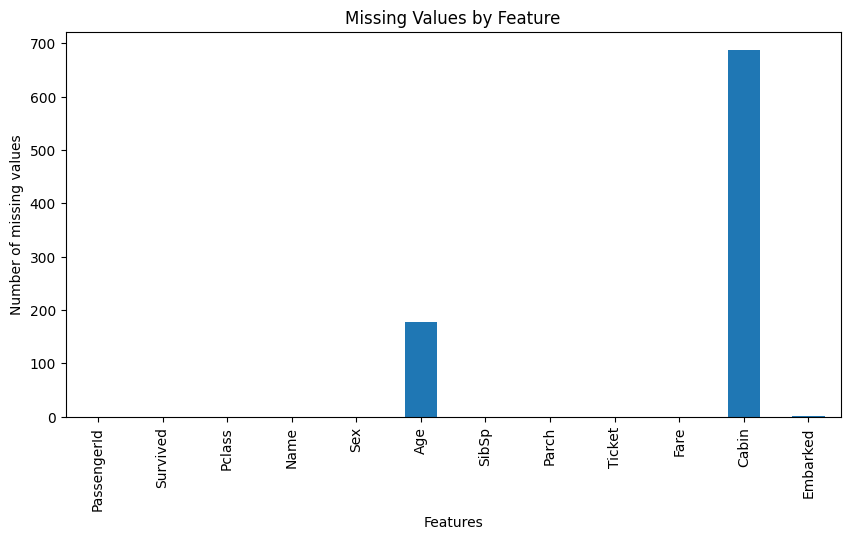

In [10]:
#Data Quality Analysis

missing = df.isnull().sum()
print("\nMissing Values:")
print(missing)

#missing percent

missing_percent  = (df.isnull().sum()/df.isnull().count())*100
print("\nMissing Values Percentage:")
print(missing_percent)

#missing table
missing_table =pd.DataFrame({'Missing Count':missing,'Missing Percent':missing_percent})
print("\nMissing Values Table:")
print(missing_table)

plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title('Missing Values by Feature')
plt.xlabel('Features')
plt.ylabel('Number of missing values')
plt.xticks(rotation=90)
plt.show()





In [15]:
#Replacing missing value by mean
df_mean =df.copy()
mean_age = df_mean['Age'].mean()
df_mean['Age'].fillna(mean_age,inplace=True)

print("\nRemaining missing Age Values: ")
print(df_mean.isnull().sum())



#Replace missing Values by Median
df_median =df.copy()
median_age = df_median['Age'].median()

df_median['Age'].fillna(median_age,inplace=True)

print("\nRemaining missing Age Values: ")

print(df_median.isnull().sum())

print("\nMean Age: ",mean_age)
print("\nMedian Age: ",median_age)



#Replace missing values by Mode -Categorical Data
df_mode =df.copy()
mode_embarked = df_mode['Embarked'].mode()[0]
df_mode['Embarked'].fillna(mode_embarked,inplace=True)

print("\nRemaining missing Embarked Values: ")
print(df_mode.isnull().sum())


Remaining missing Age Values: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Remaining missing Age Values: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Mean Age:  29.69911764705882

Median Age:  28.0

Remaining missing Embarked Values: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


/tmp/ipykernel_752/4221423225.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean['Age'].fillna(mean_age,inplace=True)
/tmp/ipykernel_752/4221423225.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [25]:
# One_hot encoding
print(df[['Sex' , 'Embarked']].head(10))

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown ='ignore'
)

encoded_data = encoder.fit_transform(df[['Sex','Embarked']])

encoded_df = pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(['Sex','Embarked']))

print(encoded_df.head(10))



#Label Encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df['Survived_encoded'] = label_encoder.fit_transform(df['Survived'])
print(df[['Survived','Survived_encoded']].head(10))





      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0         0.0       1.0         0.0         0.0         1.0           0.0
1         1.0       0.0         1.0         0.0         0.0           0.0
2         1.0       0.0         0.0         0.0         1.0           0.0
3         1.0       0.0         0.0         0.0         1.0           0.0
4         0.0       1.0         0.0         0.0         1.0           0.0
5         0.0       1.0         0.0         1.0         0.0           0.0
6         0.0       1.0         0.0         0.0         1.0           0.0
7         0.0       1.0         0.0         0.0         1.0           0.0
8         1.0       0.0         0.0         0.0         1.0           0.0
9         1.0       0.0         1.0         0.0    

In [32]:
# Min max scaling
from sklearn.preprocessing import MinMaxScaler
features = df[['Age','Fare']]
minmax = MinMaxScaler()

scaled_minmax =minmax.fit_transform(features)
minmax_df = pd.DataFrame(scaled_minmax,columns=features.columns)

print(minmax_df.head(10))




#standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_data,columns=features.columns)

print(scaled_df.head(10))

        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713
5       NaN  0.016510
6  0.673285  0.101229
7  0.019854  0.041136
8  0.334004  0.021731
9  0.170646  0.058694
        Age      Fare
0 -0.530377 -0.502445
1  0.571831  0.786845
2 -0.254825 -0.488854
3  0.365167  0.420730
4  0.365167 -0.486337
5       NaN -0.478116
6  1.674039  0.395814
7 -1.908136 -0.224083
8 -0.185937 -0.424256
9 -1.081480 -0.042956
